In [1]:
from plntxps import *

from darkplot import *

# 1/24/25 SA 450

In [2]:
SA_450_1_24 = datafile('example data/Experiment 2025-1-24 SA 450.xy')

SA_450_Au_1_24 = datafile('example data/Experiment 2025-1-24 Au SA 450.xy')

In [3]:
SA_450_1_24.list_spectra()

Index  Name          Time (min)  Comment             
0      Ti 2p         529.27      
       Peak Location
.....................................................
1      O 1s          531.13      
       Peak Location
.....................................................
2      Ti 2p         532.65      
       Peak Location
.....................................................
3      O 1s          534.52      
       Peak Location
.....................................................
4      Ti 2p         536.02      
       Peak Location
.....................................................
5      O 1s          537.88      
       Peak Location
.....................................................
6      Ti 2p         539.40      
       Peak Location
.....................................................
7      O 1s          541.25      
       Peak Location
.....................................................
8      Ti 2p         542.77      
       Peak Location
...................

O 1s peak position: 530.1178 +- 0.0141
Ti 2p peak position: 458.9028 +- 0.0209


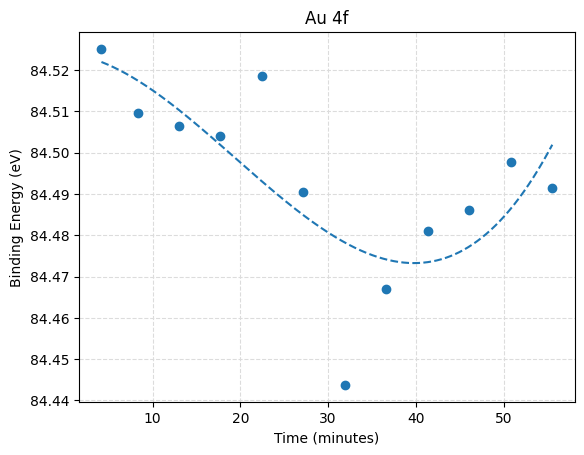

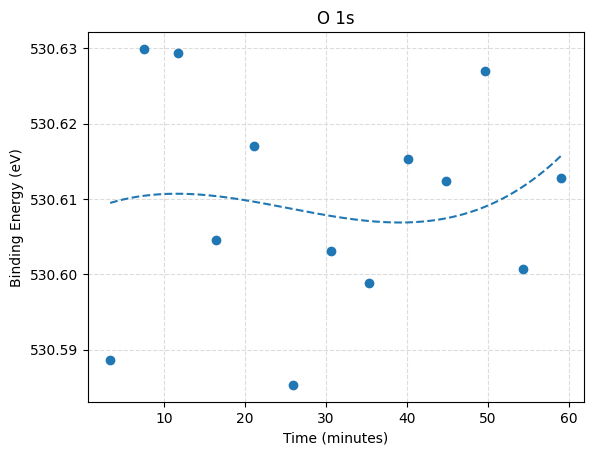

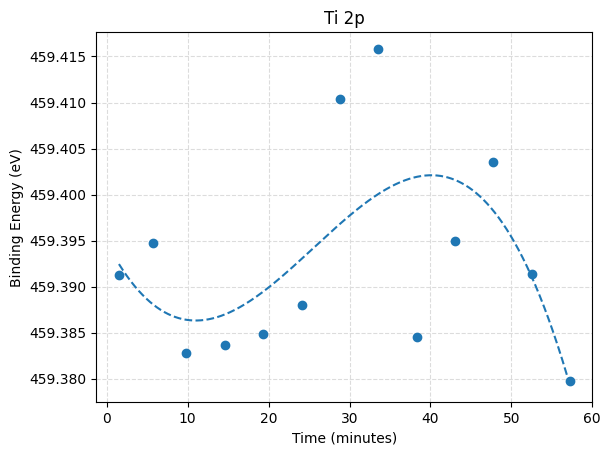

In [4]:
SA_450_Au_1_24.get_charge_referenced_peak_positions([1, 60], plot_result=True)

In [ ]:
SA_450_1_24.charge_reference_valence_band_spectra([62, 266], SA_450_Au_1_24)

time slice excludes 8 of 150 valence band spectra


In [ ]:
SA_450_1_24.find_fermi_edge_linfit([0.5, 2.5], [3.7, 4.3], instrumental_broadening = 0)
plt.xlim(14.5, -2.5)
plt.savefig('fermi_edge_linfit.svg')
plt.savefig('fermi_edge_linfit.png')

In [ ]:
SA_450_1_24.find_fermi_edge(7E7, 3.85)
plt.savefig('fermi_edge_seconddir.svg')
plt.savefig('fermi_edge_seconddir.png')

# 9-16-24 RhAl2O3 for Marlon

In [ ]:
RhAl2O3 = datafile("example data/2024-09-16 Rh on Al2O3 for Marlon 7-21-24 fit.xy")

# 6-15-26 UPS of LaB6

In [ ]:
LaB6 = read_datafile("example data/6-12-26 UPS on LaB6.xy")

In [ ]:
LaB6.list_spectra()

In [ ]:
LaB6.spectrum_table()

In [ ]:
for index, spectrum in enumerate(LaB6.spectra):
    print(f"{index}: {len(spectrum.scans)/5}")

In [ ]:
plt.plot(LaB6.spectra[17].eV, LaB6.spectra[17].counts, label = '410 nm source')
plt.plot(LaB6.spectra[17].eV, LaB6.spectra[17].masked_counts(channel_mask=[3]),
        label = '410 nm source (masked channel 3)')
plt.plot(LaB6.spectra[17].eV, LaB6.spectra[17].masked_counts(scan_mask=[1]),
        label = '410 nm source (masked scan 1)')
plt.legend()
plt.gca().invert_xaxis()
plt.xlabel('Binding Energy (eV)')
plt.ylabel("Counts per second")
plt.grid(color = 'gainsboro', ls = 'dashed')

# satellite peak fitting

In [ ]:
satellites = read_satellite_peaks('example data/perkin elmer mg satellites.csv')

In [ ]:
# generate fake data

def source_peak(eV, shift, intensity):
    return np.exp(-((eV-250 + shift)**2)/10)*intensity

rng = np.random.default_rng(seed = 1)

eV = np.arange(100, 300, 0.1)[::-1]
counts = np.zeros(len(eV)) + rng.normal(0, 1, size = eV.shape)
for satellite in satellites.values():
    counts += source_peak(eV, satellite['position'], satellite['intensity'])
plt.plot(eV, counts)
plt.gca().invert_xaxis()

In [ ]:
result = fit_procedure(eV, counts, ['example'], "example data/fit params.csv",
          bg_type = 'none', satellites = satellites,
          plot_guess = True, plot_result = True)